# 5. Factor research on synthetic data (runs anywhere)

This notebook exercises the **whole research engine without a database or a Refinitiv session**.
It is the quickest way to understand how the pieces fit together, and it doubles as a smoke test
after any code change.

| Step | Library call |
|---|---|
| Build a price panel and a quarterly fundamentals history | `tests.unit_tests.synthetic` (stand-in for `data_engineering`) |
| Clean the price panel | `analytics.data_quality.neutralize_single_day_glitches` |
| Momentum signal | `analytics.factors.MomentumFactor` |
| Point-in-time value signal | `InMemoryFundamentalsProvider` + `analytics.factors.ValueFactor.compute_dynamic` |
| Blend and rebalance monthly | `analytics.factors.CompositeFactor` |
| Signal → dollar-neutral weights | `analytics.portfolio.quantile_weights` |
| Weights → returns, costs, statistics | `analytics.backtest.run_backtest` |
| Signal quality | `information_coefficient`, `quantile_returns` |

Swap the synthetic frames for the real ones (`database.read_market_data` → pivot, `StaticFundamentalsProvider`)
and every subsequent cell runs unchanged — that is what notebook **04** does.

> The data is random. Nothing here says anything about real markets; the point is the plumbing.

In [1]:
import numpy as np
import pandas as pd

from analytics.backtest import (
    forward_returns, ic_summary, information_coefficient, prices_to_returns, quantile_returns, run_backtest,
)
from analytics.data_quality import describe_panel, neutralize_single_day_glitches
from analytics.factors import CompositeFactor, MomentumFactor, ValueFactor
from analytics.performance.plots import plot_cumulative_returns, plot_drawdowns
from analytics.portfolio import month_starts, quantile_weights
from data_engineering.fundamentals import InMemoryFundamentalsProvider
from tests.unit_tests.synthetic import synthetic_fundamentals_history, synthetic_prices

pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## 5.1 Parameters

Everything a research run depends on is declared once, up front.

In [2]:
N_SECURITIES = 60
N_DAYS = 900                       # ~3.5 years of business days
MOMENTUM_LOOKBACK, MOMENTUM_SKIP = 252, 21   # classic 12-1 momentum
REBALANCE = "M"                    # refresh the composite on the first trading day of each month
QUANTILE = 0.1                     # top / bottom decile
COST_BPS = 10                      # one-way transaction cost per unit of turnover
AVAILABILITY_LAG_DAYS = 45         # fundamentals become usable 45 days after the fiscal period end

## 5.2 Data

`synthetic_prices` produces a geometric random walk with a persistent per-security drift, so momentum has
something to detect. `synthetic_fundamentals_history` produces one 18-ratio panel per fiscal quarter with
the same shape the Refinitiv provider returns (`security_id, effective_date, *RATIO_COLUMNS`).

In [3]:
prices = synthetic_prices(N_SECURITIES, N_DAYS, seed=11)
quarter_ends = pd.date_range(prices.index[0] - pd.offsets.QuarterEnd(2), prices.index[-1], freq="QE")
history = synthetic_fundamentals_history(list(prices.columns), quarter_ends, seed=3)

print("price panel:", prices.shape, "| fundamentals rows:", len(history), "| quarters:", history["effective_date"].nunique())
history.head(3)

price panel: (900, 60) | fundamentals rows: 900 | quarters: 15


,security_id,effective_date,EV/EBIT,Op. In./(NWC+FA),P/E,P/B,P/S,Op. In./Interest Expense,Working Capital Ratio,RoE,ROCE,Debt/Equity,Debt Ratio,Cash Ratio,Asset Turnover,Gross Profit Margin,(CA-CL)/TA,RE/TA,EBIT/TA,Book Equity/TL
0,1001,2020-09-30,23.3048,0.1439,49.9405,1.1222,1.2602,4.0518,1.5982,0.1136,0.1114,0.6411,0.1909,0.6283,0.9358,0.2812,0.0842,0.3598,0.0677,0.3548
1,1002,2020-09-30,41.5478,0.0421,-19.9000,3.1125,1.4269,13.3265,1.0781,0.0747,0.0309,1.0761,0.5291,0.4894,1.2409,0.2542,0.0166,0.3187,0.1800,0.7357
2,1003,2020-09-30,13.8151,0.1261,22.1851,1.6823,2.5769,20.5372,1.6121,0.2595,0.0192,0.4320,0.2693,0.9087,1.0677,0.5601,0.0299,0.2457,0.0697,0.4682


## 5.3 Data quality

Vendor feeds contain one-day "V-shaped" bad prints. We inject a few and let `neutralize_single_day_glitches`
find them: a print that moves more than 50% and reverts the next session is replaced by the previous price;
genuine crashes (which do not revert) are left alone.

In [4]:
dirty = prices.copy()
rng = np.random.default_rng(1)
for col in dirty.columns[:4]:
    dirty.loc[dirty.index[rng.integers(30, N_DAYS - 30)], col] *= 0.05
print("before:", describe_panel(dirty))
prices_clean, n_fixed = neutralize_single_day_glitches(dirty, threshold=0.5)
print("after :", describe_panel(prices_clean), "| glitches neutralised:", n_fixed)
# the glitch day now carries the previous close, so it differs from the true price by at most one day's move
max_gap = (prices_clean / prices - 1).abs().max().max()
print(f"largest remaining gap vs the true panel: {max_gap:.2%} (a normal daily move); rows changed: {int((prices_clean != prices).sum().sum())}")
assert n_fixed == 4

before: {'dates': 900, 'securities': 60, 'mean_coverage': 1.0, 'min_coverage': 1.0, 'non_positive_prices': 0, 'single_day_glitches': 4}
after : {'dates': 900, 'securities': 60, 'mean_coverage': 1.0, 'min_coverage': 1.0, 'non_positive_prices': 0, 'single_day_glitches': 0} | glitches neutralised: 4
largest remaining gap vs the true panel: 1.14% (a normal daily move); rows changed: 4


## 5.4 Momentum

`MomentumFactor(252, 21)` is the return from t‑273 to t‑21: the most recent month is skipped to avoid short-term
reversal. The **information coefficient** (Spearman rank correlation between today's signal and the next
month's return) and the mean return per signal quintile tell us whether the signal orders stocks correctly.

In [5]:
momentum = MomentumFactor(MOMENTUM_LOOKBACK, MOMENTUM_SKIP).compute(prices_clean)
fwd_1m = forward_returns(prices_clean, 21)
rebalance_dates = month_starts(prices_clean.index)

ic_mom = information_coefficient(momentum.loc[rebalance_dates], fwd_1m.loc[rebalance_dates])
print("momentum IC:", {k: round(v, 3) for k, v in ic_summary(ic_mom).items()})
quantile_returns(momentum.loc[rebalance_dates], fwd_1m.loc[rebalance_dates], 5).mean().rename("mean 1m fwd return by momentum quintile").to_frame().T

momentum IC: {'mean_ic': 0.115, 't_stat': np.float64(4.459), 'ic_ir': np.float64(2.919), 'pct_positive': 0.821, 'n': 28}


s,1,2,3,4,5
mean 1m fwd return by momentum quintile,-0.0025,-0.0007,0.0084,0.0105,0.0193


## 5.5 Point-in-time value

`InMemoryFundamentalsProvider` answers "what did we know on date *d*?" — only rows whose fiscal period ended
at least `AVAILABILITY_LAG_DAYS` before *d* are visible. `ValueFactor.compute_dynamic` re-scores the panel on
every rebalance date and carries the score forward, so the value signal refreshes as new filings arrive and
never sees the future. The same call works with `StaticFundamentalsProvider` against the database.

In [6]:
provider = InMemoryFundamentalsProvider(history, availability_lag_days=AVAILABILITY_LAG_DAYS)
symbols = pd.DataFrame({"security_id": prices_clean.columns})
value = ValueFactor().compute_dynamic(prices_clean, lambda d: provider.get_panel(symbols, d.strftime("%Y-%m-%d")), dates=rebalance_dates)

print("value signal first defined on:", value.dropna(how="all").index[0].date(), "| coverage on last day:", int(value.iloc[-1].notna().sum()))
ic_val = information_coefficient(value.loc[rebalance_dates], fwd_1m.loc[rebalance_dates])
print("value IC (random fundamentals -> expect ~0):", {k: round(v, 3) for k, v in ic_summary(ic_val).items()})

value signal first defined on: 2021-01-01 | coverage on last day: 60
value IC (random fundamentals -> expect ~0): {'mean_ic': 0.007, 't_stat': np.float64(0.307), 'ic_ir': np.float64(0.166), 'pct_positive': 0.634, 'n': 41}


## 5.6 Composite signal, weights and backtest

`CompositeFactor` z-scores each component cross-sectionally, averages them with the given weights and refreshes
the blend on the rebalance dates. `quantile_weights` turns the signal into an equal-weighted, dollar-neutral
top/bottom-decile book. `run_backtest` applies **yesterday's** weights to today's returns (`shift_weights=1`)
and charges `COST_BPS` per unit of one-way turnover.

In [7]:
composite = CompositeFactor({"momentum": momentum, "value": value}, weights={"momentum": 0.5, "value": 0.5},
                            rebalance_dates=rebalance_dates).compute(prices_clean)
asset_returns = prices_to_returns(prices_clean)

books = {
    "MOMENTUM_LS": quantile_weights(momentum.loc[rebalance_dates].reindex(prices_clean.index).ffill(), QUANTILE),
    "VALUE_LS": quantile_weights(value, QUANTILE),
    "COMPOSITE_LS": quantile_weights(composite, QUANTILE),
}
result = run_backtest(books, asset_returns, shift_weights=1, cost_bps=COST_BPS)
result.summary().round(3)

,total_return,cagr,volatility,sharpe,sortino,max_drawdown,calmar,hit_rate,periods,annual_turnover
MOMENTUM_LS,0.7970,0.1780,0.1130,1.5040,2.3530,-0.1430,1.2490,0.3720,900,4.4800
VALUE_LS,0.1340,0.0360,0.1370,0.3250,0.4670,-0.1700,0.2120,0.5220,900,7.0930
COMPOSITE_LS,1.3140,0.2650,0.1430,1.7160,2.6110,-0.1440,1.8360,0.5590,900,8.3530


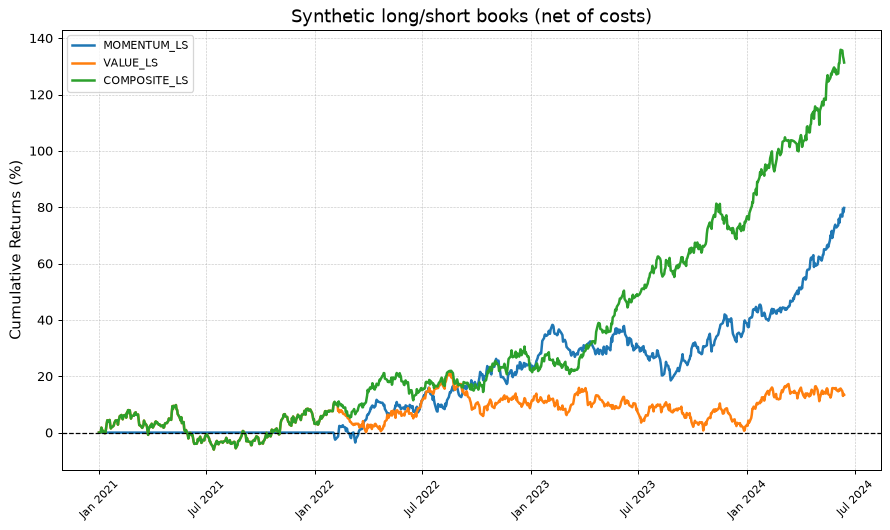

In [8]:
fig = plot_cumulative_returns(result.returns.dropna(how="all"), title="Synthetic long/short books (net of costs)")
fig

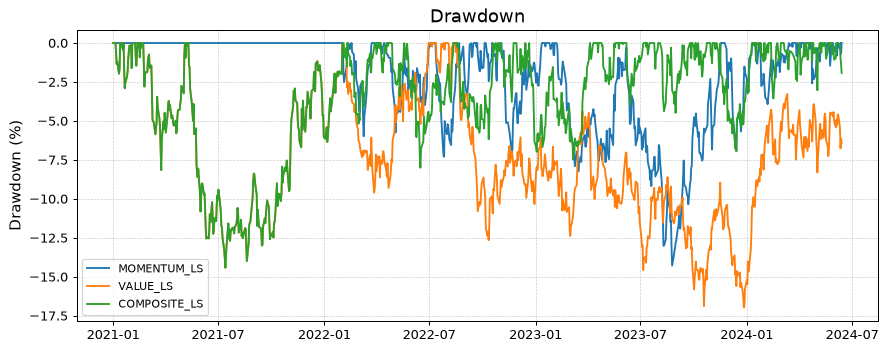

In [9]:
fig = plot_drawdowns(result.returns.dropna(how="all"))
fig

## 5.7 What the costs did

Gross vs net returns and the average turnover per book. A monthly-rebalanced decile book turns over a large share
of its names every month, which is why costs matter and why lower-frequency signals (or holding-period buffers)
are worth testing.

In [10]:
compare = pd.DataFrame({
    "gross_total_return": (1 + result.gross_returns).prod() - 1,
    "net_total_return": (1 + result.returns).prod() - 1,
    "annual_cost_drag": result.costs.mean() * 252,
    "avg_monthly_one_way_turnover": result.turnover().mean() * 21,
})
compare.round(4)

,gross_total_return,net_total_return,annual_cost_drag,avg_monthly_one_way_turnover
MOMENTUM_LS,0.8264,0.7974,0.0045,0.3733
VALUE_LS,0.1632,0.1342,0.0071,0.5911
COMPOSITE_LS,1.3833,1.3135,0.0084,0.6961


## 5.8 Where to go from here

* Replace the synthetic inputs with `database.read_market_data(...)` and `StaticFundamentalsProvider(...)` — see notebook **04**.
* Add the ML value signal: train with `analytics.factors.ml_training.train_models` and pass an `MLReturnFactor`
  into `compute_dynamic` exactly like `ValueFactor` above.
* Ideas for stronger signals and a more realistic portfolio are collected in `docs/STRATEGY_IMPROVEMENTS.md`.